# Week 2 lab: gradient descent

On Tuesday we found the derivative of the loss with respect to a parameter, and saw that its sign tells you which direction that parameter should move. Knowing the direction is not the same as arriving. Today we take that step, then repeat it, then learn to read what a sequence of steps tells you about whether a model is training properly.

Run the cells in order from the top.

Passages marked **Aside** go a little past what we cover in class. They are there if you want them, and skipping them on a first pass costs you nothing.

In [57]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

---

## What the loss measures

A model that makes a prediction for every data point also makes an error for every data point. With forty points, that is forty separate numbers describing how wrong the model is. Forty numbers are hard to compare against another forty and impossible to search with, so they have to be reduced to one. That single number is the **loss**, and the convention is that smaller means better.

Tuesday introduced mean squared error, which is the loss we use today. The recipe has three steps. Take the error at each point, which is the prediction minus the truth. Square it. Average the squares.

$$\text{MSE} = \text{mean}\left(\left(\hat{y} - y\right)^2\right)$$

The squaring does two separate jobs, and it is worth separating them.

The first job is to remove the signs. An error of +2 and an error of -2 are equally wrong, but averaging them directly would let them cancel and report no error at all. Tuesday's flat line through the average penguin mass did exactly that: it was wrong about nearly every bird and still scored close to zero, because its overestimates and underestimates destroyed each other. Squaring makes every error positive, so they can only accumulate.

The second job is less obvious. Squaring does not treat all errors proportionally.

| error | squared |
|---|---|
| -1 | 1 |
| +2 | 4 |
| -3 | 9 |

The third error is three times the size of the first and contributes nine times as much to the loss. That is not a flaw. It follows directly from squaring, and it is what the tool does. It does have a consequence you should expect: a model fitted with squared error will move its line to reduce one very large miss, even when that makes every other point slightly worse. The third exercise puts that behavior in your hands.

## The data

Today's data is generated rather than measured, and that is a deliberate choice for one day. Tuesday's penguins came with units and a story, which is what made the slope readable out loud. Today the subject is the machinery itself, so the data is stripped down to a plain `x` and `y` with nothing to interpret.

Generating it buys something in exchange. Because we built the data, we know the line it came from: `w_true = 3` and `b_true = 7`, with random noise added on top. Every fit you produce today can be compared against the correct answer. When you fit real data that answer does not exist, and there is no way to check the model except against more data. Today it is printed at the top of the notebook.

In [58]:
torch.manual_seed(0)

x = torch.linspace(0.0, 10.0, 40)
noise = torch.randn(40) * 1.5
y = 3.0 * x + 7.0 + noise

w_true, b_true = 3.0, 7.0

print(f"x runs from {x.min():.1f} to {x.max():.1f}, {len(x)} points")
print(f"made with w_true = {w_true}, b_true = {b_true}, noise scale 1.5")

x runs from 0.0 to 10.0, 40 points
made with w_true = 3.0, b_true = 7.0, noise scale 1.5


`torch.manual_seed(0)` fixes the random number generator so that everyone in the room gets the same forty points with the same noise. Without it each of you would get different data, and none of the numbers printed in this notebook would match yours.

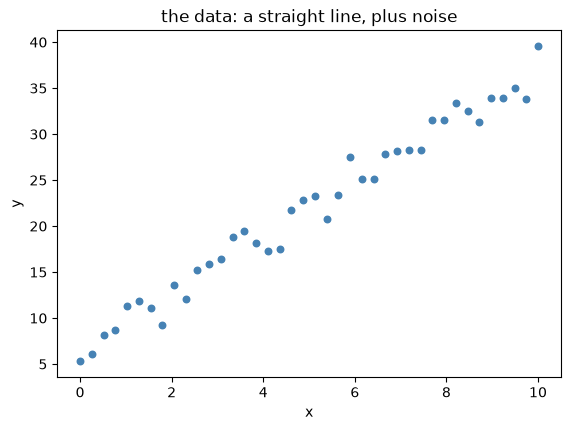

In [59]:
plt.figure(figsize=(6.5, 4.5))
plt.scatter(x, y, s=22, color="steelblue")
plt.xlabel("x")
plt.ylabel("y")
plt.title("the data: a straight line, plus noise")
plt.show()

The points lie near a line without lying on it, because of the noise. Fitting means recovering the line they were generated from, using only the points.

## The loss as a function of the weight

There are two parameters to find, `w` and `b`, and it is easier to look at one at a time. For this section the bias is held fixed at `b = 7.0`, which is its true value. That is borrowed information and we will not lean on it for long. Finding `b` is the same problem as finding `w`, solved the same way, and the loop later in this notebook finds both at once.

Tuesday's first strategy was to score a range of candidate weights and keep whichever scored best. Here it is on this data:

In [60]:
b_fixed = 7.0

print("     w      loss")
for w_try in torch.linspace(0.0, 6.0, 13):
    errors = w_try * x + b_fixed - y
    print(f"  {w_try:4.1f}  {(errors ** 2).mean():8.2f}")

     w      loss
   0.0    305.76
   0.5    212.94
   1.0    137.00
   1.5     77.95
   2.0     35.77
   2.5     10.48
   3.0      2.06
   3.5     10.53
   4.0     35.87
   4.5     78.10
   5.0    137.20
   5.5    213.19
   6.0    306.06


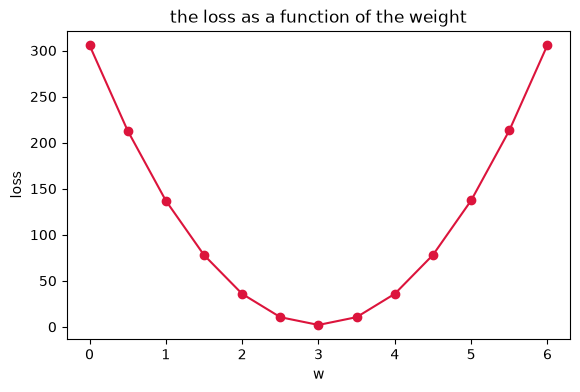

In [61]:
ws = torch.linspace(0.0, 6.0, 13)
losses = []
for w_try in ws:
    errors = w_try * x + b_fixed - y
    losses.append(float((errors ** 2).mean()))

plt.figure(figsize=(6.5, 4))
plt.plot(ws, losses, marker="o", color="crimson")
plt.xlabel("w")
plt.ylabel("loss")
plt.title("the loss as a function of the weight")
plt.show()

The curve falls, reaches a minimum near `w = 3.0`, and rises again.

The horizontal axis deserves a second look, because it is not the kind of quantity plots usually put there. It is not a measurement of anything in the world. It is a parameter, a number we choose. Every point on this curve represents an entire model, one particular choice of `w`, scored against all forty data points at once. Moving to the right along the axis does not mean looking at a different sample. It means considering a different model.

The shape tells us the problem is solvable. There is a lowest point, and the whole task is to find it.

## Finding the direction

Scanning the range worked, but it scored thirteen models to learn one thing, and it does not scale. Tuesday's count showed that two parameters at eleven values each is 121 models, and six parameters is over a million.

The alternative is to stop trying to see the whole curve and ask a local question instead. Standing at one particular value of `w`, which direction is down?

Start at `w = 2.0` and measure what happens to the loss when `w` increases slightly:

In [62]:
w_now = 2.8
h = 0.1

here = float(((w_now * x + b_fixed - y) ** 2).mean())
right = float((((w_now + h) * x + b_fixed - y) ** 2).mean())
rate = (right - here) / h

print(f"loss at w = {w_now:.1f}    : {here:.2f}")
print(f"loss at w = {w_now + h:.1f}    : {right:.2f}")
print(f"change per unit of w : {rate:+.2f}")

loss at w = 2.8    : 3.40
loss at w = 2.9    : 2.39
change per unit of w : -10.08


The loss went down when `w` went up, so increasing `w` is the right move. One measurement answered the question. There was no need to check the other direction, because if moving right lowers the loss then moving left raises it.

The third printed line is worth reading slowly, because it is the same calculation as Tuesday's slope applied to a different pair of quantities:

$$\text{rate} = \frac{\text{change in loss}}{\text{change in } w}$$

On Tuesday the slope was a change in penguin mass divided by a change in flipper length, and it read out loud as kilograms per millimeter. Here it is a change in loss divided by a change in the weight, and it reads as: for every 1 that `w` increases, the loss falls by about 64.

This rate, measured at a specific point, is the **derivative of the loss with respect to the parameter**. Two things about it matter, and they are separate.

Its **sign** tells you which way to move. A negative derivative means the loss falls as the parameter rises, so the parameter should increase. A positive derivative means the opposite.

Its **size** tells you how sharply the loss responds to this parameter right now. A derivative of -64 means the loss is changing quickly here. A derivative near zero means moving this parameter barely changes anything, which is what happens at the bottom of the curve, where there is no improvement left to find.

One vocabulary note, because both words appear in this notebook and in PyTorch's own naming. **Derivative** and **gradient** mean the same thing here. "Gradient" is the word people reach for when there is more than one parameter and they mean all of the derivatives collected together, which is why PyTorch stores the result in `w.grad`. Taking one parameter at a time, as we are, the two words are interchangeable.

Measuring the derivative by hand, the way the cell above does, has two costs. It needs a full extra pass over the data for every parameter, and it needs you to choose the step size `h` yourself. PyTorch computes the same quantity directly:

In [63]:
w_grad = torch.tensor(2.0, requires_grad=True)
b_grad = torch.tensor(7.0, requires_grad=True)

loss_grad = ((w_grad * x + b_grad - y) ** 2).mean()
loss_grad.backward()

print(f"derivative with respect to w : {w_grad.grad.item():+.2f}")
print(f"derivative with respect to b : {b_grad.grad.item():+.2f}")

derivative with respect to w : -67.47
derivative with respect to b : -9.76


Three pieces of that cell are new. `requires_grad=True` marks a tensor as one you want derivatives for, which tells PyTorch to pay attention to what happens to it. `.grad` is where the answer is stored afterwards. `.item()` pulls the single number out of a one-element tensor so that it prints cleanly.

The two numbers are close and not equal. Measured: -64.10. PyTorch: -67.47. Neither one is wrong.

> **Aside.** Our measurement moved `w` from 2.0 to 2.1 and divided the change in loss by the distance travelled, which gives the *average* slope across that whole interval. The curve bends between those two points, so its average slope across the interval is not the same as its slope at the left end. PyTorch reports the slope exactly at `w = 2.0`, with no interval involved. Making `h` smaller shrinks the disagreement, though only down to a limit, which the lecture notebook shows.

Notice also that one call to `backward()` produced derivatives for both parameters at once. The by-hand method needs a separate pass for each. How PyTorch does this is next week's subject.

Both derivatives are negative, so both parameters should increase.

## One step, and then many

We now have a direction. Acting on it means changing the parameter by some amount in that direction, which is one line of arithmetic:

$$w \leftarrow w - \text{lr} \times \frac{\partial \, \text{loss}}{\partial w}$$

That line has two symbols worth naming. The arrow means "becomes": work out the right-hand side, then store the result back into `w`. The fraction with the curly $\partial$ is a derivative, read out loud as "the derivative of the loss with respect to `w`", and it is exactly the quantity we measured a moment ago. The curly $\partial$ is used instead of a straight $d$ to signal that the loss depends on more than one parameter and we are varying only this one while holding the other still.

The minus sign is what makes this work. The derivative points in the direction the loss *increases*, so subtracting it moves in the direction the loss decreases. When the derivative is negative, as it is here, subtracting a negative value increases `w`, which is what we determined we wanted.

Running that line repeatedly is **gradient descent**, and it is the algorithm the rest of this course is built on. Here is one step of it:

In [64]:
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(7.0, requires_grad=True)

loss = ((w * x + b - y) ** 2).mean()
print(f"loss before the step : {loss.item():.2f}")

loss.backward()
print(f"gradient of w        : {w.grad.item():+.2f}")
print(f"gradient of b        : {b.grad.item():+.2f}")

lr = 0.01
with torch.no_grad():      # the update is plain arithmetic, not tracked
    w -= lr * w.grad       # move against the gradient
    b -= lr * b.grad
    w.grad.zero_()         # clear, ready for the next step
    b.grad.zero_()

new_loss = ((w * x + b - y) ** 2).mean()
print(f"w after the step     : {w.item():.3f}")
print(f"loss after the step  : {new_loss.item():.2f}")

loss before the step : 35.77
gradient of w        : -67.47
gradient of b        : -9.76
w after the step     : 2.675
loss after the step  : 5.33


The loss fell from 35.77 to 5.33 in a single step.

The `lr` in that update is the **learning rate**. The derivative tells you which way to go and how steep the ground is, but it does not tell you how far to travel. The learning rate is that decision, expressed as the fraction of the gradient to actually apply. It has its own section below.

Three lines in that cell do something that is not obvious from reading them, and each needs an explanation.

**`loss.backward()`** is what computes the derivatives and stores them. Before you call it, `w.grad` and `b.grad` hold `None`, because nothing has been calculated yet. After the call they hold numbers. If you ever find yourself looking at a gradient of `None`, the usual cause is that `backward()` was never reached.

**`with torch.no_grad():`** temporarily switches off PyTorch's recording.

To work out a derivative, PyTorch writes down every operation it performs on a tracked tensor, so that it can retrace those steps afterwards. Updating a parameter is itself an operation on a tracked tensor, so it would get written down too, and that is not what we want. The update is bookkeeping we are doing to the model from the outside. It is not part of the calculation the model performs on the data, and recording it would corrupt the notes that the next `backward()` reads. Wrapping the update in `no_grad()` says: do this arithmetic, and do not write it down.

> **Aside.** What exactly gets written down, and how retracing it produces a derivative, is next week's subject. For this week it is enough to know that the recording exists and that the update has to stay out of it.

**`w.grad.zero_()`** sets the gradient back to zero before the next step begins. This one needs more explanation than the others, because it looks like housekeeping and it is not.

When you call `backward()`, PyTorch does not replace whatever is sitting in `w.grad`. It adds to it. If `w.grad` already holds -67.5 from the previous step and this step computes -40.2, then afterwards `w.grad` holds -107.7, the sum of the two.

> **Aside.** Adding rather than replacing is a deliberate design decision and not an oversight. There are situations, which we will not meet this term, where a loss is computed in several pieces and you want their gradients summed before taking one step. PyTorch supports that by making addition the default, and asks you to clear the total yourself whenever that is not what you wanted.

The cost is that ordinary training has to clear the gradient by hand on every pass. A loop that forgets this line does not crash. It builds a running total of every gradient so far, uses that total as though it were the current gradient, and pushes the parameter much too far in a direction that stopped being correct several steps ago. The last exercise has a run where you can watch that happen.

Those lines are identical on every step, so the next cell packages them into a function. It takes the loss function as an argument rather than fixing it, which matters in the third exercise, where you swap the loss and watch the answer change.

In [65]:
def step(w, b, x, y, lr, loss_fn):
    """One step of gradient descent. Returns the loss, as a plain number."""
    loss = loss_fn(w, b, x, y)   # score the model with the given loss
    loss.backward()              # fill in the gradients of w and b
    with torch.no_grad():        # the update is plain arithmetic, not tracked
        w -= lr * w.grad         # move each parameter against its gradient
        b -= lr * b.grad
        w.grad.zero_()           # clear, ready for the next step
        b.grad.zero_()
    return loss.item()

In [66]:
def squared_loss(w, b, x, y):
    """Mean squared error."""
    return ((w * x + b - y) ** 2).mean()

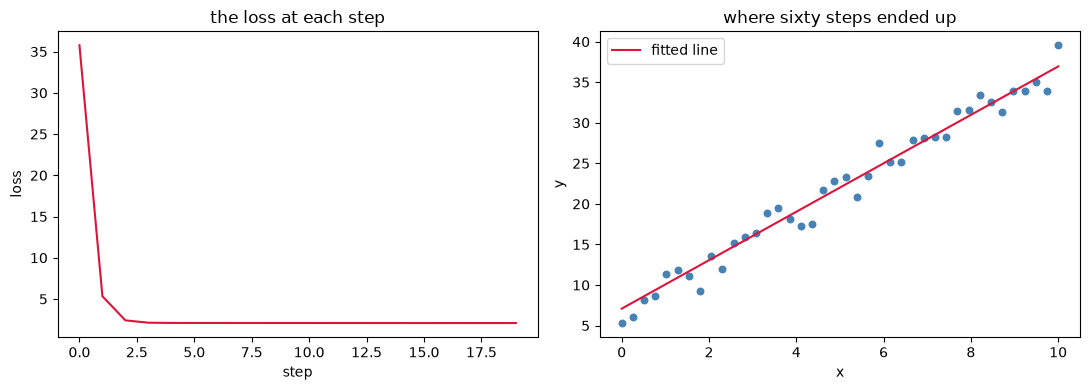

walked to: w = 2.986, b = 7.088
truth:     w = 3.0, b = 7.0


In [67]:
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(7.0, requires_grad=True)

demo_losses = []
for i in range(20):
    demo_losses.append(step(w, b, x, y, 0.01, squared_loss))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(demo_losses, color="crimson")
ax[0].set_xlabel("step")
ax[0].set_ylabel("loss")
ax[0].set_title("the loss at each step")

ax[1].scatter(x, y, s=22, color="steelblue")
ax[1].plot(x, w.item() * x + b.item(), color="crimson", label="fitted line")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].set_title("where sixty steps ended up")
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"walked to: w = {w.item():.3f}, b = {b.item():.3f}")
print(f"truth:     w = {w_true}, b = {b_true}")

Sixty steps landed at `w = 3.000`, `b = 6.989`, close to the `w = 3`, `b = 7` the data was built from.

Close, and not exact. The difference is not a failure of the loop.

Run long enough, this loop settles at a particular line and stays there. The word for settling at a value and staying is **converging**, and you will meet it constantly from here on.

> **Aside.** What it converges to is `w = 3.066`, `b = 6.549`, which is the best possible line for **these particular forty points**. That is not quite the line the points were generated from, because the noise added to each point is real and this sample of forty carries its own particular set of accidents. Any fitting procedure describes the sample it was handed rather than the process that produced the sample, which is why running the loop for a thousand steps instead of sixty drifts slightly further from `(3, 7)` and slightly closer to `(3.066, 6.549)`. That is correct behavior. It is the same reason a study on forty subjects does not land on exactly the number a study on four thousand would.

The loss curve on the left is worth learning to read, because you will look at thousands of these. A healthy run falls steeply at first, when the parameters are far from where they belong and the gradients are large, then flattens as it approaches the minimum and the gradients shrink toward zero. The flattening is the run reporting that it has arrived. Three shapes matter: this one, a curve still falling steeply when the run ends, which means it needed more steps or a larger learning rate, and a curve that rises, which is the next section.

Finally, compare the fitted line against a line chosen by looking at the scatter plot. A reasonable guess by eye of `w = 2.5`, `b = 8.0` scores 6.72. The loop scores 2.06, and it never saw the plot.

## The learning rate

Everything in this notebook so far has one correct answer. The learning rate does not. It is the first quantity in this course that you have to choose, where the right choice depends on the data, and where the two ways of getting it wrong produce two recognizable failures.

Here is the same loop with the learning rate raised from 0.01 to 0.05:

In [68]:
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(7.0, requires_grad=True)

big_losses = []
for i in range(25):
    big_losses.append(step(w, b, x, y, 0.05, squared_loss))

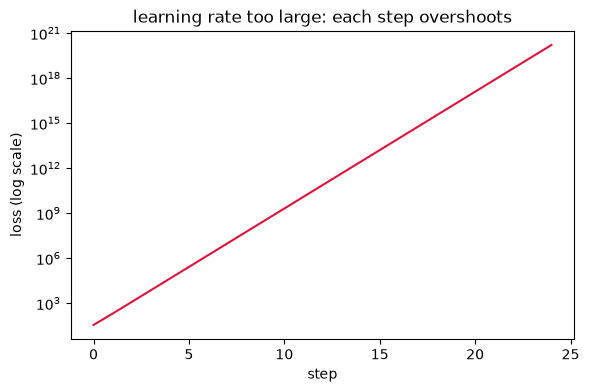

loss after 25 steps: 1.633e+20


In [69]:
plt.figure(figsize=(6.5, 4))
plt.plot(big_losses, color="crimson")
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("loss (log scale)")
plt.title("learning rate too large: each step overshoots")
plt.show()

print(f"loss after 25 steps: {big_losses[-1]:.3e}")

The loss does not decrease. It grows by a factor of about six on every step.

The plot uses a logarithmic vertical axis, where moving the same distance up the page means multiplying by the same amount rather than adding the same amount. Steady multiplication therefore draws a straight line, which is what makes this pattern easy to recognize at a glance. On an ordinary axis the same run would be a flat line that suddenly goes vertical, and you would not be able to see what happened at the start.

The mechanism is worth stating precisely. The gradient at the starting point correctly identifies which direction reduces the loss, and it continues to be correct throughout. The problem is distance. A learning rate of 0.05 makes the step large enough that `w` travels past the minimum and lands on the far side of it, higher up than where it started. The gradient at that new position is larger and points back the other way, so the next step is bigger still and overshoots further. Each step makes the following one worse. This is the most common way a first attempt at training a model fails.

The opposite mistake fails quietly:

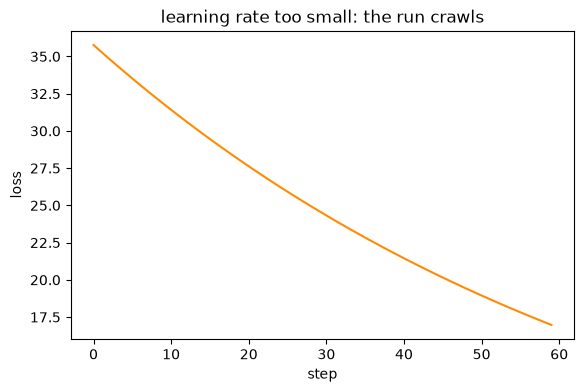

after 60 steps, w = 2.332 (still not at the truth, 3.0)
loss: 35.77 down to 16.97


In [70]:
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(7.0, requires_grad=True)

small_losses = []
for i in range(60):
    small_losses.append(step(w, b, x, y, 0.0001, squared_loss))

plt.figure(figsize=(6.5, 4))
plt.plot(small_losses, color="darkorange")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("learning rate too small: the run crawls")
plt.show()

print(f"after 60 steps, w = {w.item():.3f} (still not at the truth, 3.0)")
print(f"loss: {small_losses[0]:.2f} down to {small_losses[-1]:.2f}")

Nothing is wrong with this run except that it is far too slow. The loss decreases on every step, the direction is right, and after sixty steps it has barely moved. Given enough steps it would arrive. A run like this is harder to catch than the exploding one, because nothing about it looks broken.

There is no formula that produces the right learning rate. It depends on the scale of the data, which is why a value that works here would not work on Tuesday's penguins, where flipper lengths near 200 make the gradients enormous. The honest procedure is to try a value, look at the loss curve, and adjust. You will produce one of these two failures yourself in the exercises below.

## Choosing a loss

Everything so far has treated mean squared error as given. It is not given. It is a choice. In chooseing a loss function, you are deciding what constitutes a good fit. It is the place where you tell the model what the word "wrong" means. Change it and you change what the model considers a good answer. This makes consideration of what our loss function is doing a central part of the modeling process, and it is worth pausing to look at alternatives.

The most common alternative is mean absolute error, which averages the sizes of the errors rather than their squares:

$$\text{MAE} = \text{mean}\left(\left|\hat{y} - y\right|\right)$$

It drops into the same loop with no other changes. Same parameters, same gradients, same update rule. The only difference is the definition of the number being made small.

That one difference changes the answer, and it changes it in a way you already have a name for. Making squared error as small as possible against a set of numbers lands you on their **mean**. Making absolute error as small as possible against the same numbers lands you on their **median**. Everything you know about how those two behave carries straight over: one extreme value drags the mean, and mostly leaves the median where it was.

The third exercise shows both halves of that, first on five numbers you can check by hand, then on the full fit.

---
# Lab Section:
## Your turn

Work in pairs. One laptop drives and both of you think, and switch who is typing between exercises.

Cells marked **YOUR TURN** contain blanks written as `...`, which you fill in. The cell immediately after each one checks your answer and tells you whether it is right, so you are never left guessing whether something worked.

Each exercise opens with the functions it needs, so you do not have to hunt for a name. The `step` function is already defined above and does not need rewriting. Its signature, meaning the arguments it expects and the order they go in:

```
step(w, b, x, y, lr, loss_fn)  ->  the loss at the start of the step, as a plain number
```

---

### 1. A line chosen by eye

Pick a line by looking at the data, then score it. That score is the number everything else in this notebook has to beat.

**Functions you need:**

- `w * x + b` gives every prediction at once, one per data point
- `w * x + b - y` gives every error at once, prediction minus truth
- `tensor ** 2` squares every element
- `tensor.mean()` averages a tensor down to one number

Scroll back to the scatter plot and choose a slope and an intercept that look right to you. The values below are a starting point and yours should be different:

In [74]:
w_by_eye = 3.5
b_by_eye = 7

Look at the first six predictions next to the true values, the same way Tuesday's table did. Run this cell as it is:

In [75]:
print("    x     y_hat      y    error")
for i in range(6):
    y_hat = w_by_eye * x[i] + b_by_eye
    print(f"{x[i]:5.1f}  {y_hat:6.2f}  {y[i]:6.2f}  {y_hat - y[i]:+6.2f}")

    x     y_hat      y    error
  0.0    7.00    5.31   +1.69
  0.3    7.90    6.04   +1.86
  0.5    8.79    8.16   +0.63
  0.8    9.69    8.66   +1.04
  1.0   10.59   11.35   -0.76
  1.3   11.49   11.88   -0.40


Before computing anything, say out loud to your partner whether you expect your loss to be closer to 1, 5, or 20. Commit to an answer first. Checking a prediction against a result teaches you more than reading the result on its own.

Now compute it. Two blanks, one line each:

In [ ]:
# YOUR TURN
errors = w_by_eye * x + b_by_eye - y    # prediction minus truth, for every point at once
loss_by_eye =            # square the errors, then average them. This would be something like errors ^ 2, and then what?

print(f"loss of the by-eye line: {loss_by_eye:.2f}")

TypeError: unsupported format string passed to ellipsis.__format__

Check yourself against PyTorch's own mean squared error. If your number is right, these two agree to four decimals:

In [ ]:
reference = F.mse_loss(w_by_eye * x + b_by_eye, y)

print(f"yours     : {loss_by_eye:.4f}")
print(f"PyTorch's : {reference:.4f}")
print("match" if abs(float(loss_by_eye) - float(reference)) < 1e-4 else "not yet, check the two blanks above")

Checking a piece you wrote against a reference implementation is a habit worth building now. It costs one line, and it catches the errors that produce plausible wrong numbers instead of crashing.

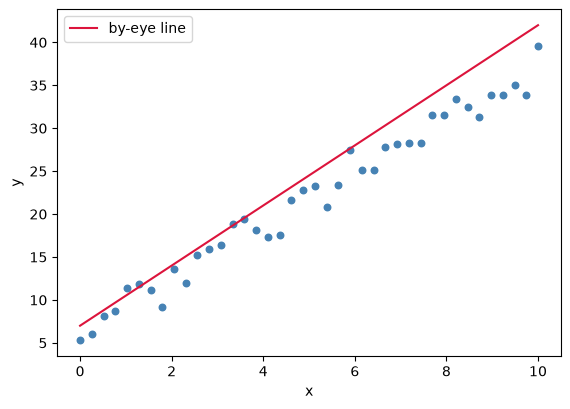

In [76]:
plt.figure(figsize=(6.5, 4.5))
plt.scatter(x, y, s=22, color="steelblue")
plt.plot(x, w_by_eye * x + b_by_eye, color="crimson", label="by-eye line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Keep `loss_by_eye`. You need it again at the end of the notebook.

---

### 2. Writing the loop

Turn a single step into a full run, then break it deliberately.

**Functions you need:**

- `step(w, b, x, y, lr, loss_fn)` runs one step and returns that step's loss
- `squared_loss` is the loss function to hand it, already defined above
- `torch.tensor(2.0, requires_grad=True)` makes a parameter with gradient tracking on
- `a_list.append(value)` adds to the end of a list
- `for i in range(60):` repeats 60 times

The parameters start at the same values used earlier. Write a loop that runs sixty times, taking one step each pass and keeping the loss that `step` returns.

In [81]:
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(7.0, requires_grad=True)
lr = 0.01

my_losses = []

# YOUR TURN: loop 60 times. Each pass, call step(...) and append what it returns to my_losses.
for i in range(60):
    my_losses.append(step(w, b, x, y, lr, squared_loss))
...

Ellipsis

Check that it ran:

In [82]:
print(f"steps taken   : {len(my_losses)}")
print(f"loss at start : {my_losses[0]:.2f}")
print(f"loss at end   : {my_losses[-1]:.2f}")
print(f"walked to     : w = {w.item():.3f}, b = {b.item():.3f}")
print(f"truth         : w = {w_true}, b = {b_true}")
print("looks right" if len(my_losses) == 60 and my_losses[-1] < my_losses[0]
      else "not yet: the loss should end lower than it started, over 60 steps")

steps taken   : 60
loss at start : 35.77
loss at end   : 2.06
walked to     : w = 3.000, b = 6.989
truth         : w = 3.0, b = 7.0
looks right


Now plot it. Run this cell as it is:

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(my_losses, color="crimson")
ax[0].set_xlabel("step")
ax[0].set_ylabel("loss")
ax[0].set_title("your loss at each step")

ax[1].scatter(x, y, s=22, color="steelblue")
ax[1].plot(x, w.item() * x + b.item(), color="crimson", label="your fitted line")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].legend()

plt.tight_layout()
plt.show()

The comparison that matters:

In [ ]:
print(f"your by-eye line : {loss_by_eye:.2f}")
print(f"your fitted line : {my_losses[-1]:.2f}")

The fitted line should score better than the one you chose. If it does not, something in the loop is wrong, and the shape of the loss curve is usually the fastest way to see what.

Now break it deliberately. Run the same loop with the learning rate raised from 0.01 to 0.05, and twenty-five steps instead of sixty. Do not repair it afterwards. Keep the broken plot, because the shape it produces is the thing to recognize, and you are asked about it at the end of the notebook.

In [ ]:
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(7.0, requires_grad=True)

# YOUR TURN: same loop as above, 25 times instead of 60, with lr = 0.05.
broken_losses = []
...

In [ ]:
plt.figure(figsize=(6.5, 4))
plt.plot(broken_losses, color="crimson")
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("loss (log scale)")
plt.title("learning rate too large, your own run")
plt.show()

print(f"loss at step 0  : {broken_losses[0]:.2f}")
print(f"loss at step 24 : {broken_losses[-1]:.3e}")
print(f"w ended at      : {w.item():.3e}")
print("broken as intended" if len(broken_losses) == 25 and broken_losses[-1] > broken_losses[0]
      else "not yet: you want 25 steps at lr = 0.05, and the loss should end HIGHER than it started")

---

### 3. Changing the loss

Build mean absolute error, watch it pick the median where squared error picks the mean, then add one bad data point and see which fit survives it.

**Functions you need:**

- `tensor.abs()` gives the size of every element, dropping the sign
- `tensor.mean()` averages
- `torch.cat([a, b])` glues two tensors end to end
- `torch.tensor([100.0])` makes a one-element tensor, the shape `torch.cat` wants

Mean absolute error is built the same way as mean squared error with one change: instead of squaring each error, take its size. Here is `squared_loss` again as a template. Write its counterpart underneath:

In [ ]:
def squared_loss(w, b, x, y):
    """Mean squared error: average of the squared errors."""
    errors = w * x + b - y
    return (errors ** 2).mean()

In [ ]:
# YOUR TURN
def absolute_loss(w, b, x, y):
    """Mean absolute error: average of the sizes of the errors."""
    errors = ...            # same as always: prediction minus truth
    return ...              # size of each error, then average

Check it on a case you can do in your head. Errors of -1, +2 and -3 have sizes 1, 2 and 3, so the mean absolute error is 2, while the mean squared error is 14/3.

In [ ]:
x_tiny = torch.tensor([1.0, 2.0, 3.0])
y_tiny = torch.tensor([2.0, 0.0, 6.0])     # errors of -1, +2, -3 when w = 1, b = 0

print(f"your absolute_loss : {absolute_loss(1.0, 0.0, x_tiny, y_tiny):.4f}   (should be 2.0000)")
print(f"squared_loss       : {squared_loss(1.0, 0.0, x_tiny, y_tiny):.4f}   (should be 4.6667)")

#### Which value does each loss choose?

Before fitting a line, look at the simplest possible case: five repeated readings of one quantity, where the last one went wrong.

In [ ]:
readings = torch.tensor([4.0, 4.2, 4.1, 4.3, 12.0])   # four consistent, one bad

print(f"mean of the readings   : {readings.mean():.2f}")
print(f"median of the readings : {readings.median():.2f}")

If you had to summarize those five numbers with a single value, squared error and absolute error would not give you the same one. Say out loud which value each of them lands on before you run the next cell.

Rather than fitting, just score every candidate value and see where each loss bottoms out. This is the same scan from the beginning of the notebook, on one parameter:

In [ ]:
candidates = torch.linspace(3.0, 13.0, 1001)
mse_scores = torch.stack([((c - readings) ** 2).mean() for c in candidates])
mae_scores = torch.stack([(c - readings).abs().mean() for c in candidates])

print(f"value that minimizes squared error  : {candidates[mse_scores.argmin()]:.2f}")
print(f"value that minimizes absolute error : {candidates[mae_scores.argmin()]:.2f}")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

for a, scores, name, color in [(ax[0], mse_scores, "squared error", "crimson"),
                               (ax[1], mae_scores, "absolute error", "darkorange")]:
    a.plot(candidates, scores, color=color, lw=2)
    a.axvline(float(readings.mean()), color="steelblue", ls="--", lw=1.5, label="mean, 5.72")
    a.axvline(float(readings.median()), color="seagreen", ls=":", lw=2, label="median, 4.20")
    a.scatter(readings, [0] * len(readings), s=40, color="gray", zorder=5, label="the readings")
    a.set_xlabel("candidate value")
    a.set_ylabel(name)
    a.set_title(f"{name} bottoms out at...")
    a.legend(fontsize=8)

plt.tight_layout()
plt.show()

Squared error bottoms out at 5.72, the mean. Absolute error bottoms out at 4.20, the median.

Notice that 5.72 is not close to any of the five readings. Four of them sit near 4.1 and one sits at 12, and the mean lands in the empty space between. The median ignores how far away the bad reading is and only counts that it is one value out of five, so it stays with the group.

That is the whole story of the next experiment, in miniature. A line fitted with squared error behaves like a mean and gets dragged. A line fitted with absolute error behaves like a median and mostly does not.

#### The same effect, on a fit

Now the experiment. At `x = 10` the true line puts `y` near 37. Add one extra point there with a value of 100 instead. Points like this turn up in real data through mismeasurement, a transcription slip, or an instrument fault, and they almost never arrive labeled as such.

In [ ]:
x_out = torch.cat([x, torch.tensor([10.0])])
y_out = torch.cat([y, torch.tensor([100.0])])

print(f"points before : {len(x)}")
print(f"points after  : {len(x_out)}")

Run the same loop twice on the extended data, once with each loss. Same starting point, same learning rate, same number of steps. The only difference is the loss function:

In [ ]:
w_sq = torch.tensor(2.0, requires_grad=True)
b_sq = torch.tensor(7.0, requires_grad=True)
for i in range(60):
    step(w_sq, b_sq, x_out, y_out, 0.01, squared_loss)

w_ab = torch.tensor(2.0, requires_grad=True)
b_ab = torch.tensor(7.0, requires_grad=True)
for i in range(60):
    step(w_ab, b_ab, x_out, y_out, 0.01, absolute_loss)

print(f"squared-error fit  : w = {w_sq.item():.3f}, b = {b_sq.item():.3f}")
print(f"absolute-error fit : w = {w_ab.item():.3f}, b = {b_ab.item():.3f}")
print(f"truth              : w = {w_true}, b = {b_true}")

The plot below has two panels. The left panel shows everything, including the added point. The right panel zooms in on the forty original points with the added point off the top of the axis, because that is where the difference between the two fitted lines is actually visible:

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

for a in ax:
    a.scatter(x, y, s=22, color="steelblue", label="the 40 real points")
    a.plot(x, w_sq.item() * x + b_sq.item(), color="crimson", linestyle="--", lw=2,
           label=f"squared-error fit (w = {w_sq.item():.2f})")
    a.plot(x, w_ab.item() * x + b_ab.item(), color="darkorange", lw=2,
           label=f"absolute-error fit (w = {w_ab.item():.2f})")
    a.set_xlabel("x")
    a.set_ylabel("y")

ax[0].scatter([10.0], [100.0], s=90, color="crimson", zorder=5, label="the added bad point")
ax[0].set_title("everything, including the bad point")
ax[0].legend(fontsize=8)

ax[1].set_ylim(float(y.min()) - 2, float(y.max()) + 2)
ax[1].set_title("zoomed on the real points, bad point off-screen")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Look at the right panel and tell your partner which line moved before reading on.

The squared-error line tilted upward toward the added point. The absolute-error line barely moved.

This is the property from the start of the notebook, now visible in an actual fit. Squaring lets the single worst error dominate the total, so a procedure that minimizes the total ends up serving that one point at the expense of every other.

> **Aside, with the arithmetic.** Measure against the absolute-error fit, which is the line that tracks the forty real points. The added point sits about 63 away from what that line predicts, while a typical real point sits about 1.2 away. Squaring widens that gap enormously: roughly 3955 for the added point against about 2.1 for a typical one. That single point is then carrying about 98 percent of the total squared error, so minimizing the total is very nearly the same as minimizing that one point on its own. The squared-error fit tilts to do exactly that, accepting a worse fit on all forty others in exchange. Under absolute error the same point contributes 63 against a typical 1.2, which is 57 percent of the total. It is still the largest single contributor by a wide margin, but the forty real points together now outweigh it.

The numbers say the same thing. Score both fits on the forty original points, which are the ones you actually care about:

In [ ]:
print(f"squared-error fit, scored on the 40 clean points  : {squared_loss(w_sq, b_sq, x, y):.3f}")
print(f"absolute-error fit, scored on the 40 clean points : {squared_loss(w_ab, b_ab, x, y):.3f}")

The fit that moved toward the bad point is worse on the uncorrupted data.

#### Which one should you actually use?

The experiment above makes absolute error look strictly better. It is not, and it is worth being clear about why, because the question comes up every time you fit anything.

Nothing about that comparison was rigged, but it did assume something: that the point at `y = 100` was **wrong**. Under that assumption absolute error is obviously the better choice, because the bad point is not evidence about the relationship being studied and you do not want the fit chasing it. A mistyped value, a failed instrument, a contaminated sample, or a transcription slip all fit that description.

Now assume the opposite. Suppose that point is real, and that it is telling you something important that the other forty points are not. A patient who reacted far outside the normal range, a plot that yielded far more than the others, a run where the reaction actually did take off. Absolute error would let forty ordinary points outvote it, and you would fit a line that quietly ignores the most informative measurement you have.

Squared error also encodes a claim about how bad big misses are, and often it is the right claim. One error of 10 contributes 100 to the total, while ten separate errors of 1 contribute 10 between them, so squared error says that a single large miss is worse than many small ones spread around. If you are predicting a dose, a concentration, or a structural load, that is usually exactly what you want. Being off by a lot once can be far more costly than being slightly off many times.

So the question to ask is not which loss is more accurate. It is:

- Do I think my extreme points are errors, or are they signal?
- Is one big miss worse than several small ones, or does it not matter how the error is distributed?

Squared error is the standard default because for most data the answer to the second question is yes, and because it corresponds to the mean, which most other statistical machinery is built around. Absolute error is what you reach for when you have real reason to distrust individual measurements.

There are also losses for problems that are not this shape at all. Predicting which category something belongs to, rather than a quantity, needs a different loss entirely, and that is a later week.

This week the point is that the choice exists, that it is yours to make, and that it is a statement about your data rather than a technical detail. How the derivative is computed for a real network, rather than for a single line, is next week.

---

### 4. If you have time

Optional. Nothing below is needed for the questions at the end.

Earlier in the notebook, `w.grad.zero_()` was described as the line that stops gradients from accumulating. This is what happens without it. Here is `step` with the two `zero_()` calls removed:

In [ ]:
def step_no_reset(w, b, x, y, lr, loss_fn):
    """One step, but forgetting to clear the gradients."""
    loss = loss_fn(w, b, x, y)
    loss.backward()
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
        # the two zero_() lines are gone
    return loss.item()

w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(7.0, requires_grad=True)

print("  step        loss     w.grad (a running total)         w")
for i in range(12):
    L = step_no_reset(w, b, x, y, 0.01, squared_loss)
    print(f"  {i:4d}  {L:12.3f}  {w.grad.item():22.2f}  {w.item():9.3f}")

Watch the middle column. It should hold the gradient computed on this step. Instead it holds the sum of every gradient computed so far, and it keeps pushing `w` in a direction that stopped being correct several steps earlier. By step 2, `w` has passed 3 and reached 4.04, well beyond the minimum, because the accumulated total was still negative long after the current gradient had turned positive. Only at step 3 does the total change sign and pull it back.

The result is neither convergence nor an explosion. The parameters circle the minimum indefinitely, with the loss cycling between roughly 2 and 42, and they would still be circling it at step 10,000.

That is what makes this failure worth producing once, deliberately, with the cause already known. A run destroyed by an oversized learning rate announces itself within a few steps. This one produces plausible-looking numbers forever and simply never arrives.

---

# Exercises

**Six questions, three points each, eighteen points total.**

Questions 1 to 3 are multiple choice and want a letter. Questions 4 to 6 want a few sentences, and several of them ask for numbers from your own runs above, so keep this notebook open while you answer them.

Work through them with your partner, then each of you submits your own copy before Tuesday's lecture, as in week 1. An incomplete submission on time is worth more than a complete one late.

---

**Q1.** In today's data, `x`, `y`, `w` and `b` are all tensors. Which pair does fitting choose?

(a) `x` and `y`
(b) `w` and `b`
(c) `w_true` and `b_true`
(d) `x` and `w`

Your answer: (  )

**Q2.** You run one step, `w = w - lr * w.grad`, and `w.grad` is negative. What happens to `w`?

(a) it increases
(b) it decreases
(c) it stays the same
(d) it depends on the sign of `b.grad`

Your answer: (  )

**Q3.** A classmate reports that their loss curve is a smooth line falling steadily and still falling at step 60, having dropped from 35 to only 31. What should they change?

(a) lower the learning rate
(b) raise the learning rate, or run more steps
(c) switch from squared error to absolute error
(d) nothing, the run is healthy

Your answer: (  )

---

**Q4.** From your exercise 1 and exercise 2 runs, fill in your own two numbers, then answer in two or three sentences.

- your by-eye loss: ______
- your fitted loss: ______

You picked the first line by looking at the plot. The loop never saw the plot. Say what the loop used instead, and why that let it do better than your eye.

Your answer:


**Q5.** In exercise 2 you raised the learning rate to 0.05 and the loss grew instead of shrinking. Give the loss at step 0 and at step 24 from your own broken run, then explain in two or three sentences what a single step is doing to `w` when the learning rate is too large. The word "overshoot" should appear in your explanation, and you should say what it overshoots.

- loss at step 0: ______
- loss at step 24: ______

Your answer:


**Q6.** In exercise 3, one bad point out of 41 pulled the squared-error line noticeably and left the absolute-error line nearly where it was. Using the error and squared-error table from the start of this notebook, explain in three or four sentences why a single point can have that much influence on one loss and so little on the other.

Your answer:


---

Submit your copy before Tuesday's lecture. If one question has you stuck, answer the others and submit anyway.

---

## Further exploration

Optional. Run it later, or not at all.

### The same loop on real measurements

Everything above ran on data built to be convenient. The inputs sit between 0 and 10, and a learning rate of 0.01 works. Real measurements do not arrive scaled for anyone's convenience. Tuesday's penguins have flipper lengths near 200, and nothing else about the problem changes: the same `step` function, the same loss, the same loop.

In [ ]:
import seaborn as sns

birds = sns.load_dataset("penguins").dropna()
flipper = torch.tensor(birds["flipper_length_mm"].to_numpy(), dtype=torch.float32)
grams = torch.tensor(birds["body_mass_g"].to_numpy(), dtype=torch.float32) / 1000

print(f"{len(flipper)} birds")
print(f"flipper : {flipper.min():.0f} to {flipper.max():.0f} mm")
print(f"mass    : {grams.min():.2f} to {grams.max():.2f} kg")
print("the best line for these birds is w = 0.0502, b = -5.872")

333 birds
flipper : 172 to 231 mm
mass    : 2.70 to 6.30 kg
the best line for these birds is w = 0.0502, b = -5.872


Try the learning rate that worked all day:

In [ ]:
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

print("  step          loss")
for i in range(8):
    L = step(w, b, flipper, grams, 0.01, squared_loss)
    print(f"  {i:4d}  {L:14.4e}")

  step          loss
     0      1.8346e+01
     1      1.1847e+07
     2      7.7859e+12
     3      5.1171e+18
     4      3.3630e+24
     5      2.2103e+30
     6             inf
     7             inf


The loss goes from eighteen, to ten million, to ten trillion, and by step 6 it prints as `inf`, meaning the value has grown too large for the computer to represent at all. Shortly after that it becomes `nan`, short for "not a number", which is what arithmetic involving infinity returns. Both appear in real training logs, and both mean the run died several steps before anyone noticed.

The cause is the one described in the learning rate section. Inputs near 200 produce very large gradients, so a step of 0.01 times the gradient jumps far past the minimum and lands higher up the other side than it began. Lower the learning rate until the run survives:

In [ ]:
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

peng_losses = []
for i in range(2000):
    peng_losses.append(step(w, b, flipper, grams, 1e-5, squared_loss))

print(f"loss at step 0    : {peng_losses[0]:.3f}")
print(f"loss at step 1999 : {peng_losses[-1]:.3f}")
print(f"walked to         : w = {w.item():.5f}, b = {b.item():.5f}")
print(f"best line         : w = 0.05015, b = -5.87210")

loss at step 0    : 18.346
loss at step 1999 : 0.320
walked to         : w = 0.02108, b = -0.00103
best line         : w = 0.05015, b = -5.87210


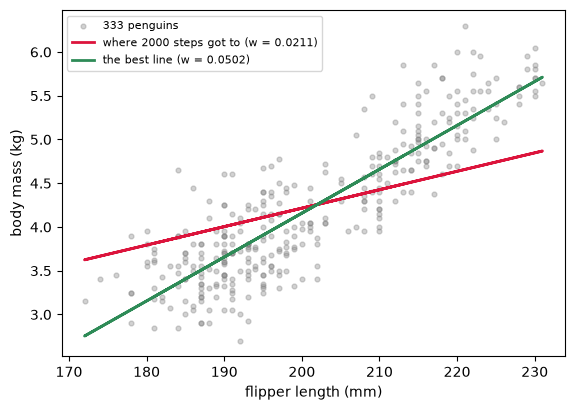

In [ ]:
plt.figure(figsize=(6.5, 4.5))
plt.scatter(flipper, grams, s=12, alpha=0.35, color="gray", label="333 penguins")
plt.plot(flipper, w.item() * flipper + b.item(), color="crimson", lw=2,
         label=f"where 2000 steps got to (w = {w.item():.4f})")
plt.plot(flipper, 0.05015 * flipper - 5.87210, color="seagreen", lw=2,
         label="the best line (w = 0.0502)")
plt.xlabel("flipper length (mm)")
plt.ylabel("body mass (kg)")
plt.legend(fontsize=8)
plt.show()

The run no longer explodes, and it also no longer arrives. After two thousand steps the line is visibly wrong and the bias is still sitting near zero.

Nothing here is broken. The loop is correct line by line. The difficulty is that the two parameters need very different step sizes. In the expression `w * x + b`, the weight is multiplied by numbers near 200 while the bias is multiplied by 1, so the gradient with respect to `w` is roughly two hundred times the size of the gradient with respect to `b`. A single learning rate has to serve both. Any value large enough to move the bias sends the weight to infinity, and any value small enough to keep the weight stable leaves the bias effectively frozen.

The standard fix is to rescale the inputs before fitting, so that every parameter sees numbers of comparable size. It is a routine and unglamorous step that goes unmentioned until it causes a problem, and it belongs to a later week. What matters today is that you have seen the problem happen, so that when it happens in your own work you will recognize it as a property of the data's scale rather than a bug in your loop.